In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
df = pd.read_csv("/content/shoes_sales_dataset.csv")
df.head()

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48


**Understanding Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   object 
 1   Date           1000 non-null   object 
 2   Brand          1000 non-null   object 
 3   Shoe_Type      1000 non-null   object 
 4   Color          1000 non-null   object 
 5   Country        1000 non-null   object 
 6   Sales_Channel  1000 non-null   object 
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


In [ ]:
df["Date"] = pd.to_datetime(df["Date"],errors="coerce")
df["Quarter"] = pd.to_datetime(df["Date"]).dt.quarter
df["Year"] = pd.to_datetime(df["Date"]).dt.year
df["Month"] = pd.to_datetime(df["Date"]).dt.month

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.groupby("Brand")["Price_USD"].mean()

,Price_USD
Brand,
Adidas,137.185636
New Balance,144.850798
Nike,131.868472
Puma,137.835449
Reebok,138.991636
Skechers,136.065867


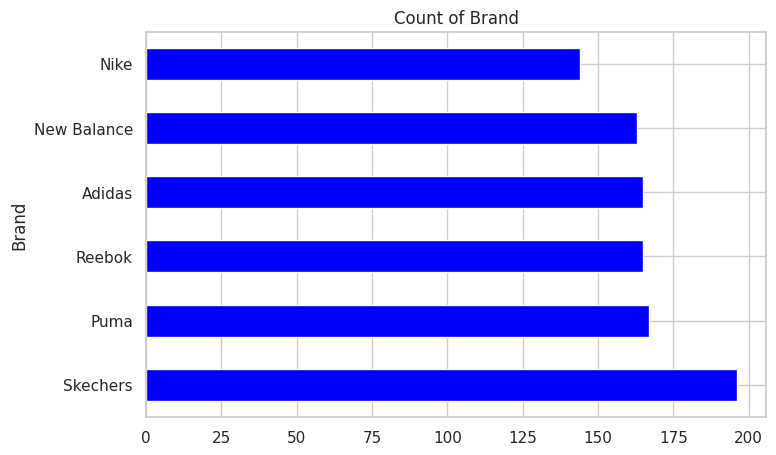

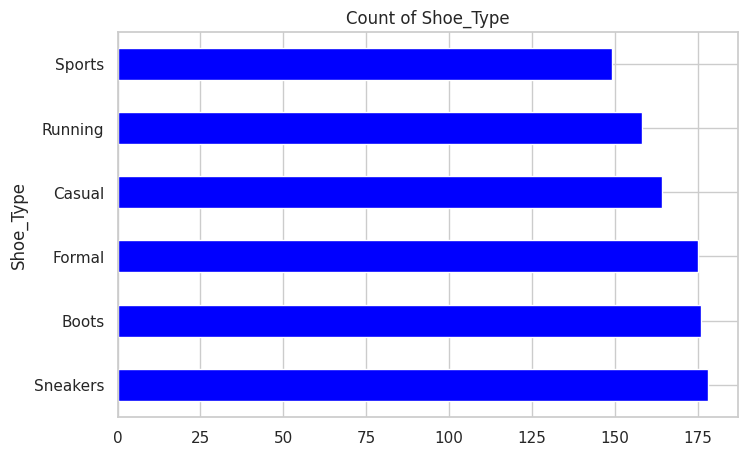

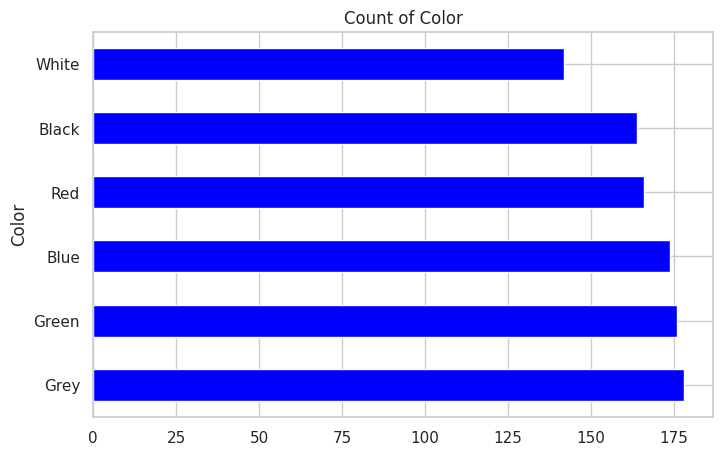

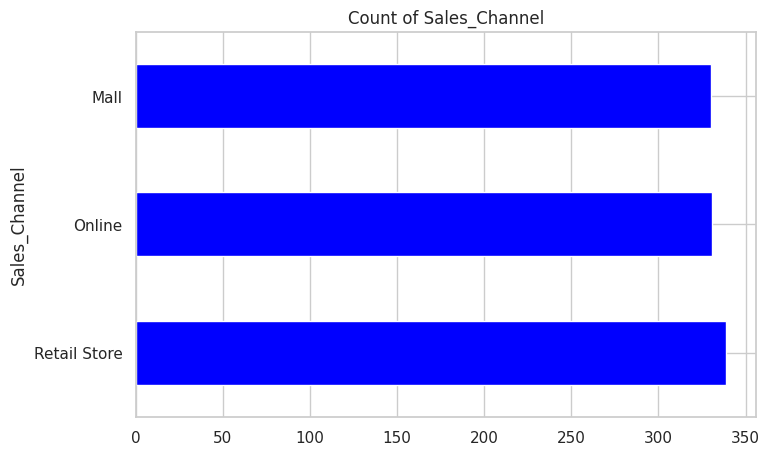

In [ ]:
cols = df[["Brand", "Shoe_Type", "Color","Sales_Channel"]].columns

for col in cols:
    plt.figure(figsize=(8, 5))
    df[col].value_counts().plot(kind="barh",color="blue")
    plt.title(f"Count of {col}")
    plt.show()

**sales analysis**

In [ ]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD', 'Quarter',
       'Year', 'Month'],
      dtype='object')

**The correlation coefficient between the price and the number of units sold is almost non-existent ($-0.015$). This means that the store's customers are not affected by price increases or decreases, which gives the management an opportunity to raise the prices of some exclusive models without the fear of losing sales**

In [ ]:
df[["Price_USD","Units_Sold","Revenue_USD"]].corr()

,Price_USD,Units_Sold,Revenue_USD
Price_USD,1.000000,-0.015693,0.591029
Units_Sold,-0.015693,1.000000,0.725185
Revenue_USD,0.591029,0.725185,1.000000


In [ ]:
a = df.groupby("Brand")["Units_Sold"].sum().sort_values(ascending=False)
a

,Units_Sold
Brand,
Skechers,1991
Adidas,1853
New Balance,1842
Puma,1727
Reebok,1700
Nike,1471


Text(0, 0.5, 'Brand')

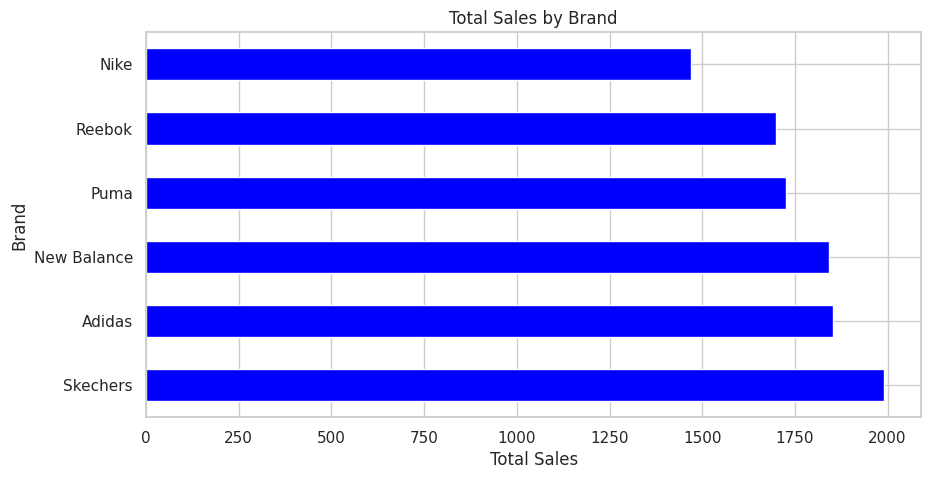

In [ ]:
a.plot(kind="barh", figsize=(10, 5),color="blue")
plt.title("Total Sales by Brand")
plt.xlabel("Total Sales")
plt.ylabel("Brand")

In [ ]:
c = df.groupby("Brand")["Revenue_USD"].sum().sort_values(ascending=False)
c

,Revenue_USD
Brand,
Skechers,269168.63
New Balance,261631.68
Adidas,257039.04
Reebok,238826.94
Puma,233749.59
Nike,192770.15


Text(0, 0.5, 'Brand')

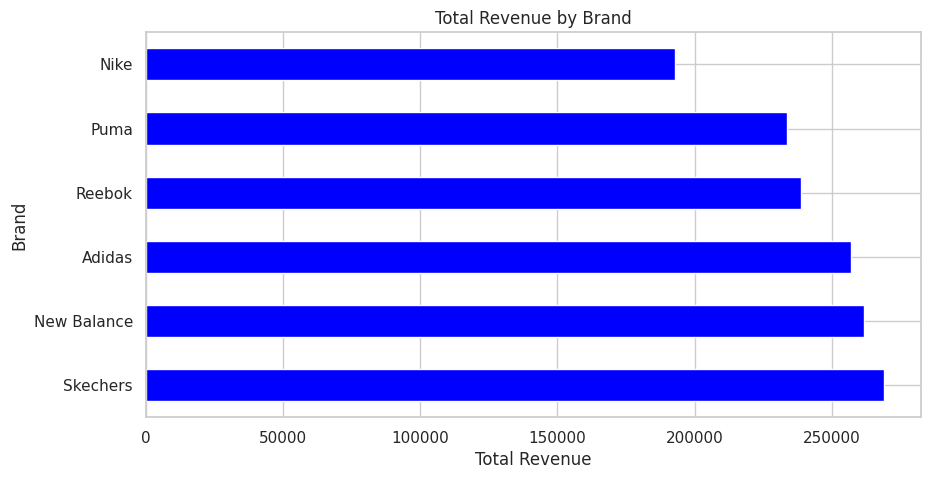

In [ ]:
c.plot(kind="barh", figsize=(10, 5),color="blue")
plt.title("Total Revenue by Brand")
plt.xlabel("Total Revenue")
plt.ylabel("Brand")

**Backed by the near-zero correlation which signals low price sensitivity, we strongly recommend implementing a strategic upward price adjustment for high-volume, lower-revenue brands like Puma. This data-driven intervention will successfully bridge the pricing gap and translate strong customer demand into maximized profit margins and higher gross revenue, without the risk of losing sales volume.**

In [ ]:
c = df.groupby("Country")["Brand"].value_counts().sort_values(ascending=False).unstack()
c

Brand,Adidas,New Balance,Nike,Puma,Reebok,Skechers
Country,,,,,,
France,31,15,21,29,19,38
Germany,15,21,28,19,27,26
India,22,28,16,28,28,24
Saudi Arabia,22,25,18,21,22,19
UAE,28,24,21,28,26,27
UK,25,21,19,18,20,31
USA,22,29,21,24,23,31


Text(0, 0.5, 'Country')

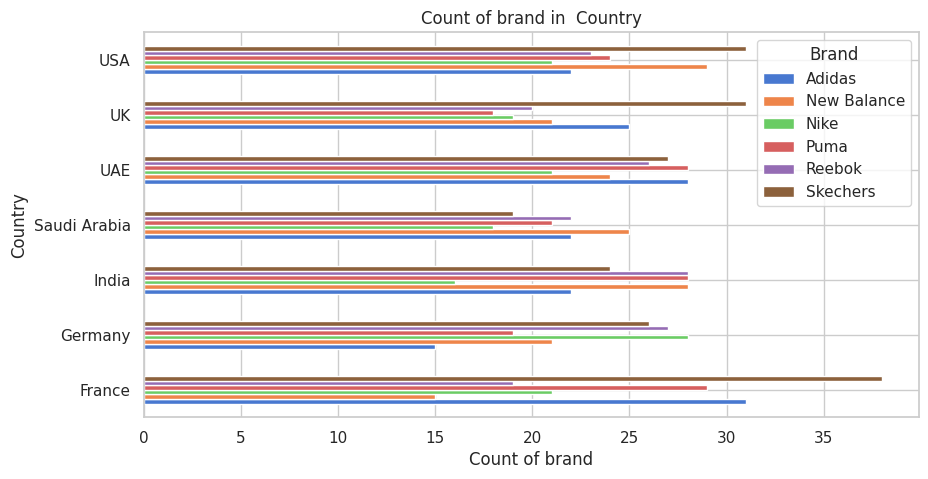

In [ ]:
c.plot(kind="barh", figsize=(10, 5))
plt.title("Count of brand in  Country")
plt.xlabel("Count of brand")
plt.ylabel("Country")


In [ ]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD', 'Quarter',
       'Year', 'Month'],
      dtype='object')

In [ ]:
c = df.groupby(["Country","Brand"])["Revenue_USD"].sum().sort_values(ascending=False).unstack()
c

Brand,Adidas,New Balance,Nike,Puma,Reebok,Skechers
Country,,,,,,
France,49183.05,23288.88,31210.88,48885.67,22547.89,52962.67
Germany,23026.16,43779.49,28165.22,27460.21,44914.92,32321.31
India,31067.47,40324.75,22180.66,24116.76,29432.34,30837.78
Saudi Arabia,34698.52,37283.93,22384.61,36312.87,37161.19,22648.70
UAE,46059.15,34955.83,31167.10,37296.08,46085.37,44244.02
UK,37428.01,29076.54,27043.83,22497.11,28039.88,42547.24
USA,35576.68,52922.26,30617.85,37180.89,30645.35,43606.91


Text(0, 0.5, 'Country')

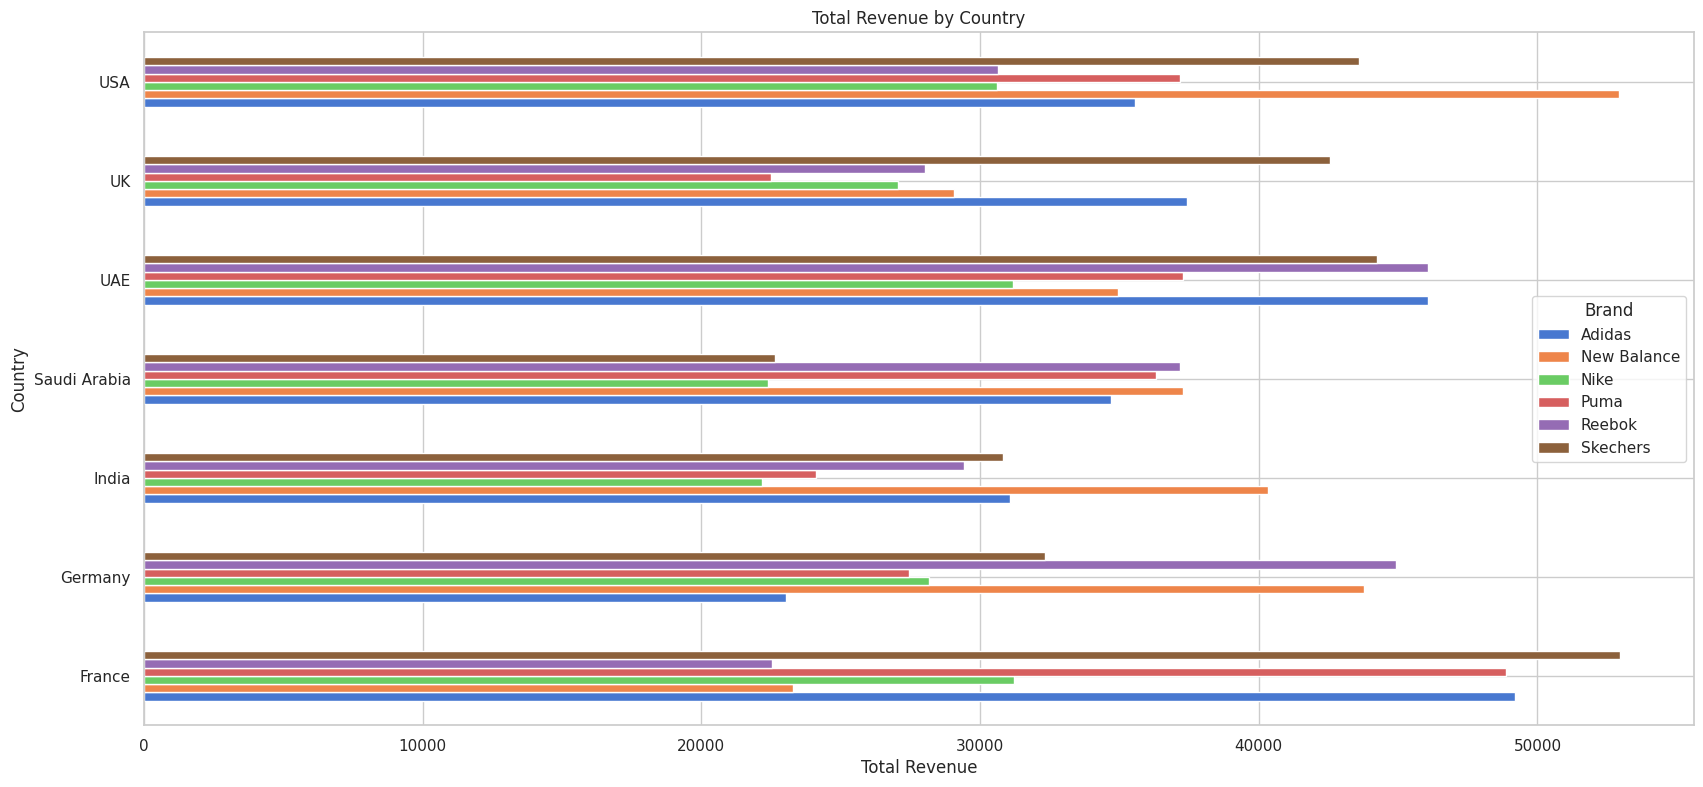

In [ ]:
c.plot(kind="barh" , figsize=(20, 9))
sns.set_theme(style="whitegrid", palette="muted")
plt.title("Total Revenue by Country")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

High-Efficiency Brands (Deserve More Expansion): Puma in France and New Balance in Germany & India show outstanding performance. These brands generate premium revenue despite having moderate to low inventory/sales counts, indicating high profit margins and strong regional demand.

Low-Efficiency Brands (Over-represented): Nike in Germany and India shows a clear operational inefficiency. It maintains a high count/frequency but yields the lowest total revenue compared to its peers, proving it does not justify its current repetitive footprint in these specific markets.

Recommendation:

Optimize Inventory and Allocation: Increase the frequency, stock, and variety of Puma in France and New Balance in Germany and India to aggressively capture the high-yielding demand.

Downsize Underperforming Brands: Reduce the repetition and visibility of Nike in the German and Indian markets, reallocating that operational capacity to high-margin brands like Skechers and New Balance to maximize overall profitability *

In [ ]:
c = df.groupby("Country")["Revenue_USD"].sum().sort_values(ascending=False)
c

,Revenue_USD
Country,
UAE,239807.55
USA,230549.94
France,228079.04
Germany,199667.31
Saudi Arabia,190489.82
UK,186632.61
India,177959.76


Text(0, 0.5, 'Country')

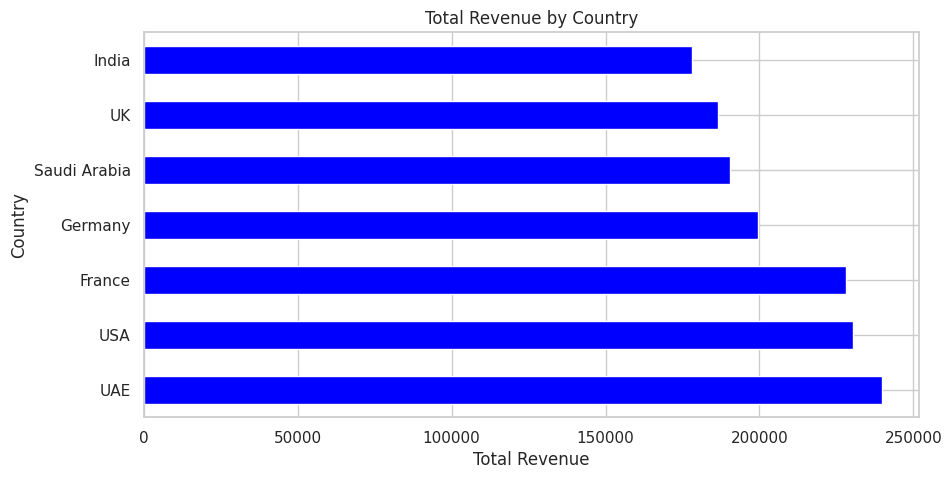

In [ ]:
c.plot(kind="barh", figsize=(10, 5),color="blue")
plt.title("Total Revenue by Country")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

In [ ]:
z = df.groupby(["Brand","Shoe_Type"])["Revenue_USD"].sum().sort_values(ascending=False).unstack()
z

Shoe_Type,Boots,Casual,Formal,Running,Sneakers,Sports
Brand,,,,,,
Adidas,50183.71,34745.35,38554.06,37825.12,63679.10,32051.70
New Balance,54219.25,39336.62,50619.07,38833.17,50486.65,28136.92
Nike,33979.63,26312.95,29066.22,29991.47,47911.53,25508.35
Puma,41055.14,41021.06,37505.78,31114.57,43394.23,39658.81
Reebok,37884.75,50502.64,40580.98,37668.19,39802.64,32387.74
Skechers,53257.61,31317.16,47382.46,54421.17,37940.88,44849.35


Text(0, 0.5, 'Brand')

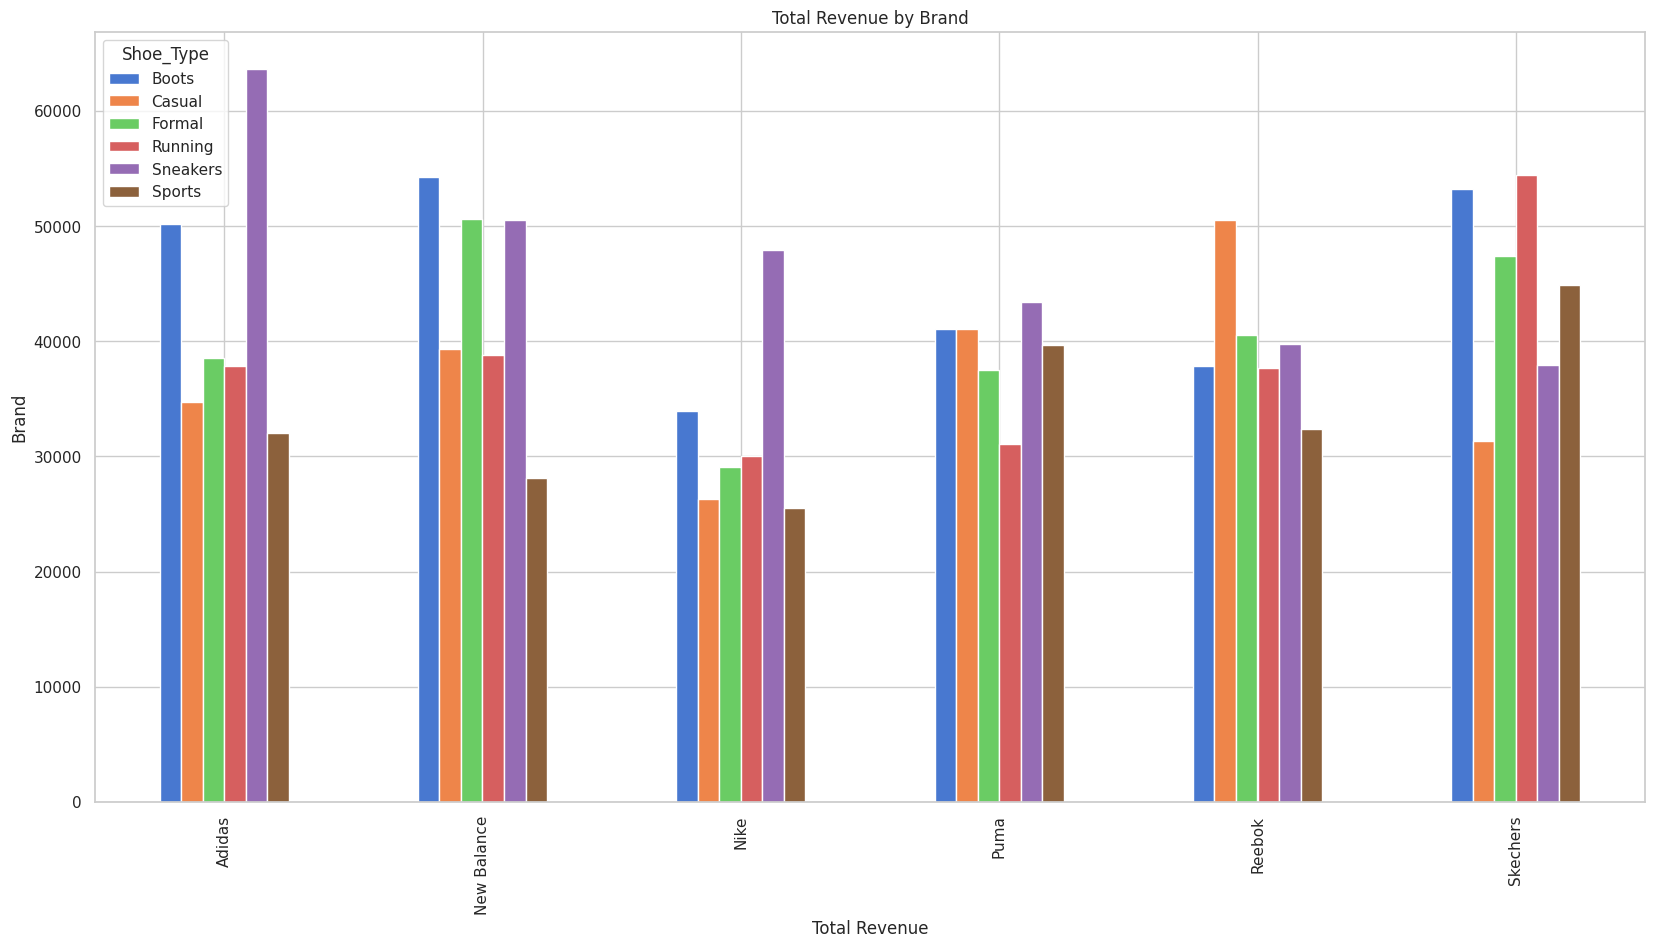

In [ ]:
z.plot(kind="bar", figsize=(20, 10))
plt.title("Total Revenue by Brand")
plt.xlabel("Total Revenue")
plt.ylabel("Brand")

In [ ]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD', 'Quarter',
       'Year', 'Month'],
      dtype='object')

In [ ]:
v = df.groupby(["Shoe_Type","Country"])["Revenue_USD"].sum().unstack()
v

Country,France,Germany,India,Saudi Arabia,UAE,UK,USA
Shoe_Type,,,,,,,
Boots,29528.22,35222.51,35146.62,36633.28,33923.72,25932.97,74192.77
Casual,35526.27,33565.47,30755.99,35554.36,34831.72,24502.62,28499.35
Formal,36011.20,33641.40,23750.99,34705.05,35671.96,43378.29,36549.68
Running,43105.19,30225.51,33467.14,19011.64,37996.28,33883.37,32164.56
Sneakers,56065.83,27108.86,31139.40,42644.33,53809.40,41605.78,30841.43
Sports,27842.33,39903.56,23699.62,21941.16,43574.47,17329.58,28302.15


Text(0, 0.5, ' Total Revenue')

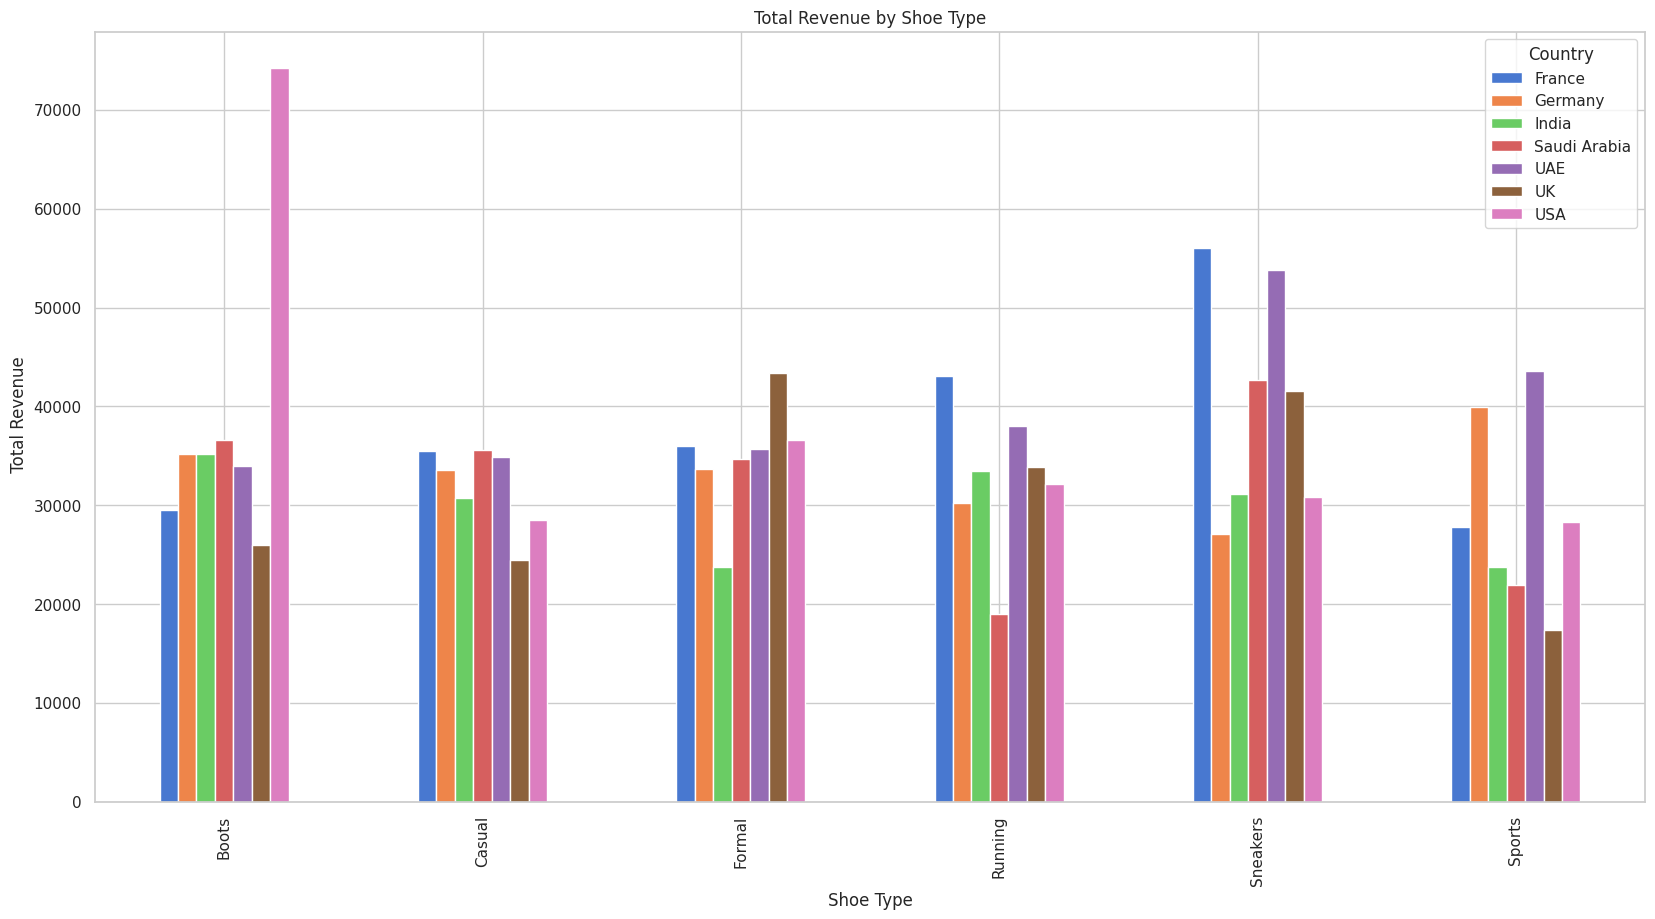

In [ ]:
v.plot(kind="bar", figsize=(20, 10))
plt.title("Total Revenue by Shoe Type")
plt.xlabel("Shoe Type")
plt.ylabel(" Total Revenue")

High-Yield Opportunities (Growth Drivers): Boots command an extraordinary revenue milestone in the USA, with New Balance and Skechers driving the highest returns in this category. Concurrently, Sneakers represent the primary revenue pillar in France and the UAE, heavily driven by Adidas’ stellar performance.

Low-Yield Deadweight (Loss Prevention): Sports and Running shoes exhibit poor performance and minimal revenue generation in the UK and Saudi Arabia, indicating that high inventory allocation in these categories results in deadstock and operational inefficiencies.

Recommendation:

Aggressive Expansion on High-Performers: Allocate aggressive inventory budgets to Boots in the USA market (leveraging New Balance/Skechers) and Sneakers in France and the UAE (leveraging Adidas) to capture high-margin turnover.

Inventory Downsizing & Mitigation: Strategically reduce the supply of Sports and Running shoes in the UK and Saudi Arabian branches. Reallocate that operational capital and shelf space toward locally preferred categories, such as Formal shoes in the UK, to eliminate waste and maximize ROI.

In [ ]:
x = df.groupby(["Brand","Shoe_Type","Country"])["Revenue_USD"].sum().sort_values(ascending=False).unstack()
x

Country                  France   Germany  ...        UK       USA
Brand       Shoe_Type                      ...                    
Adidas      Boots       7527.49   4076.95  ...   3534.56  17793.68
            Casual      5213.98   2667.64  ...   3209.69   5589.96
            Formal      7540.01   7971.06  ...   4980.51   3754.73
            Running    12817.31   4866.85  ...   6339.79   1965.68
            Sneakers   11948.46    128.08  ...  10369.31   5979.73
            Sports      4135.80   3315.58  ...   8994.15    492.90
New Balance Boots       1440.84   7984.15  ...   6687.20  15976.91
            Casual      5861.71   8641.83  ...       NaN   7041.68
            Formal      3567.39   2973.20  ...  12667.83   9839.00
            Running     8661.88       NaN  ...   5996.94  11025.74
            Sneakers    3328.20  16218.35  ...   3724.57   7270.08
            Sports       428.86   7961.96  ...       NaN   1768.85
Nike        Boots        909.45   4530.60  ...   3723.25   9305.30
            Casual      4154.46   7327.99  ...   2982.24    653.44
            Formal      7662.87   3006.54  ...   2276.36   3955.09
            Running     1894.68   2518.19  ...  10313.36   4476.11
            Sneakers   11114.30   2935.75  ...   7283.53   3302.19
            Sports      5475.12   7846.15  ...    465.09   8925.72
Puma        Boots      12703.75   1660.66  ...   1243.56   3839.55
            Casual      9228.14    732.96  ...   6452.52   7930.34
            Formal      3007.98   7625.74  ...   4194.05   6068.31
            Running     7637.11   5442.43  ...    856.76   5940.84
            Sneakers   10591.60   5136.38  ...   5320.87   6742.05
            Sports      5717.09   6862.04  ...   4429.35   6659.80
Reebok      Boots       3133.38   4622.71  ...   5105.97  14439.13
            Casual      3913.90   7930.38  ...   3194.70   5058.63
            Formal      3983.49   7574.18  ...  10503.49   3444.31
            Running     4556.98  12723.30  ...   6876.60   1757.59
            Sneakers    6548.18   1479.02  ...   1210.00   4165.72
            Sports       411.96  10585.33  ...   1149.12   1779.97
Skechers    Boots       3813.31  12347.44  ...   5638.43  12838.20
            Casual      7154.08   6264.67  ...   8663.47   2225.30
            Formal     10249.46   4490.68  ...   8756.05   9488.24
            Running     7537.23   4674.74  ...   3499.92   6998.60
            Sneakers   12535.09   1211.28  ...  13697.50   3381.66
            Sports     11673.50   3332.50  ...   2291.87   8674.91

[36 rows x 7 columns]

In [ ]:
c = df.groupby("Color")["Revenue_USD"].sum().sort_values(ascending=False)
c

,Revenue_USD
Color,
Grey,257491.78
Blue,256975.27
Green,255616.02
Black,242202.37
Red,229577.85
White,211322.74


Text(0, 0.5, 'Color')

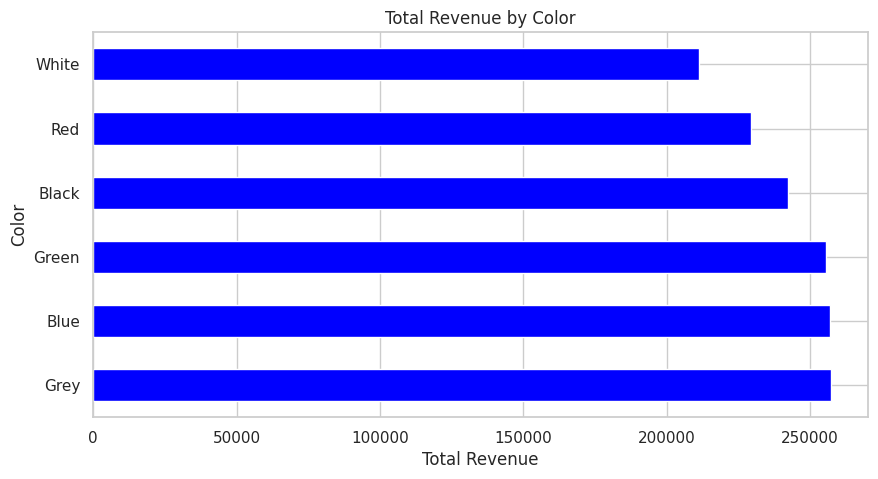

In [ ]:
c.plot(kind="barh", figsize=(10, 5),color="blue")
plt.title("Total Revenue by Color")
plt.xlabel("Total Revenue")
plt.ylabel("Color")

In [ ]:
b = df.groupby(["Color","Shoe_Type"])["Revenue_USD"].sum().sort_values(ascending=False).unstack()
b

Shoe_Type,Boots,Casual,Formal,Running,Sneakers,Sports
Color,,,,,,
Black,36217.06,48362.44,39900.55,37950.77,42687.23,37084.32
Blue,55095.23,25574.21,41764.06,32957.94,47944.95,53638.88
Green,36891.91,40885.07,58117.61,37297.84,49522.39,32901.20
Grey,56429.50,48083.46,38223.79,41340.70,50017.34,23396.99
Red,42567.39,41600.20,29306.56,46231.19,39169.58,30702.93
White,43379.00,18730.40,36396.00,34075.25,53873.54,24868.55


Text(0, 0.5, ' Total Revenue')

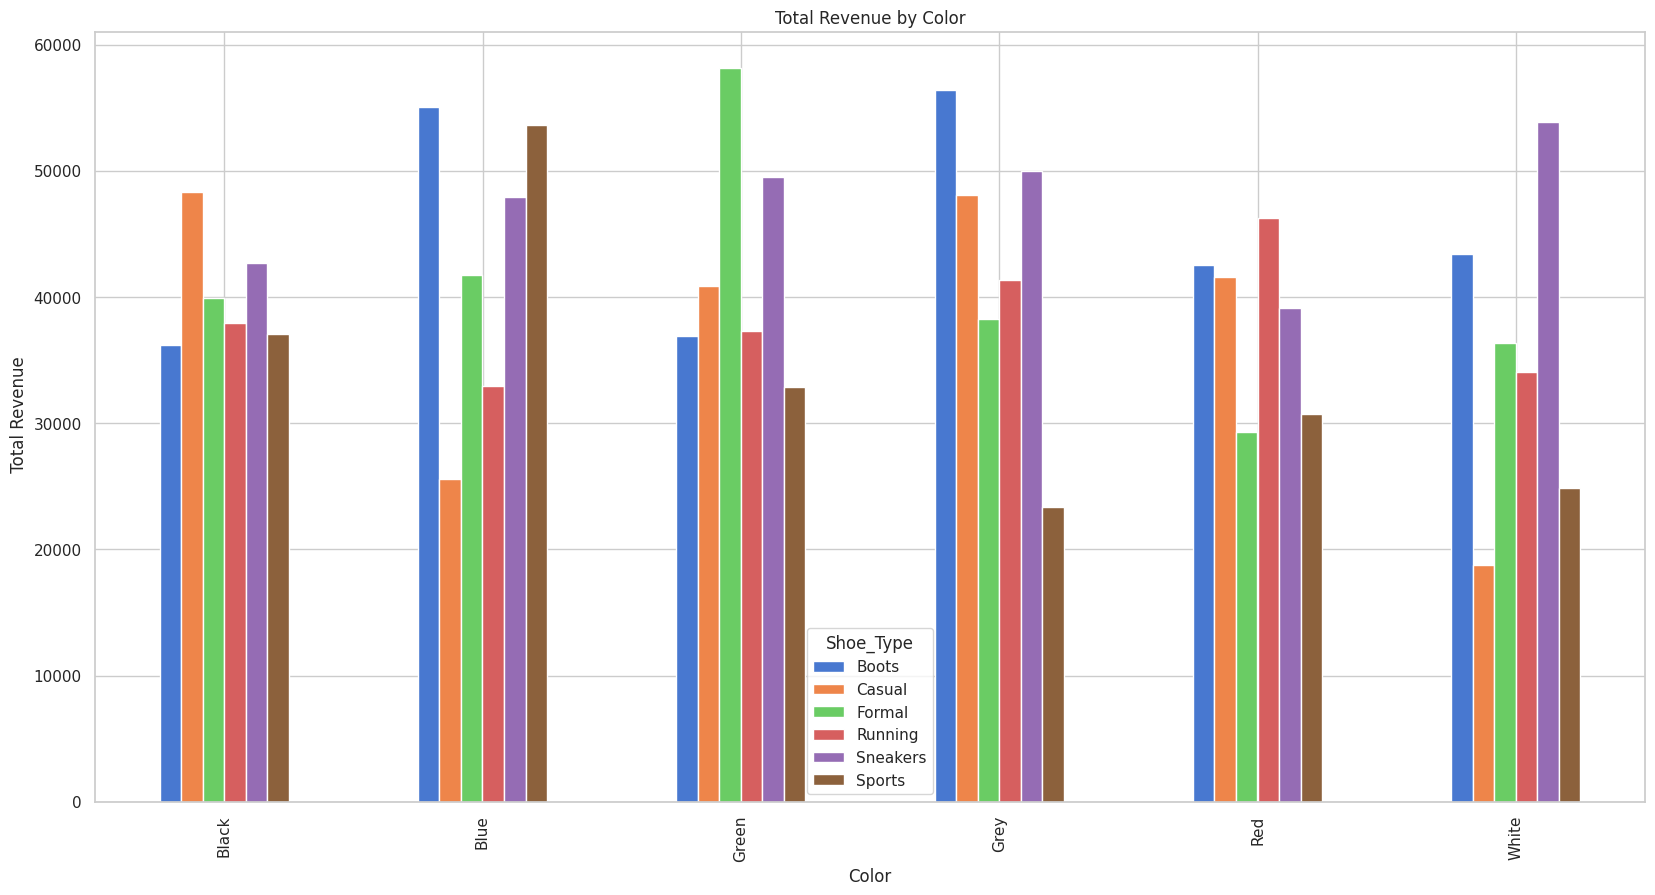

In [ ]:
b.plot(kind="bar", figsize=(20, 10))
plt.title("Total Revenue by Color")
plt.xlabel("Color")
plt.ylabel(" Total Revenue")

In [ ]:
 n = df.groupby(["Color","Brand"])["Revenue_USD"].sum().unstack()
 n

Brand,Adidas,New Balance,Nike,Puma,Reebok,Skechers
Color,,,,,,
Black,31601.46,32988.48,27841.14,63524.64,38149.45,48097.20
Blue,40513.67,57093.09,30855.07,51392.17,33100.23,44021.04
Green,53968.15,40112.05,37257.68,30432.28,49732.08,44113.78
Grey,42605.72,60526.88,43995.94,23101.87,36413.90,50847.47
Red,44437.02,35212.09,32805.50,40154.05,33740.27,43228.92
White,43913.02,35699.09,20014.82,25144.58,47691.01,38860.22


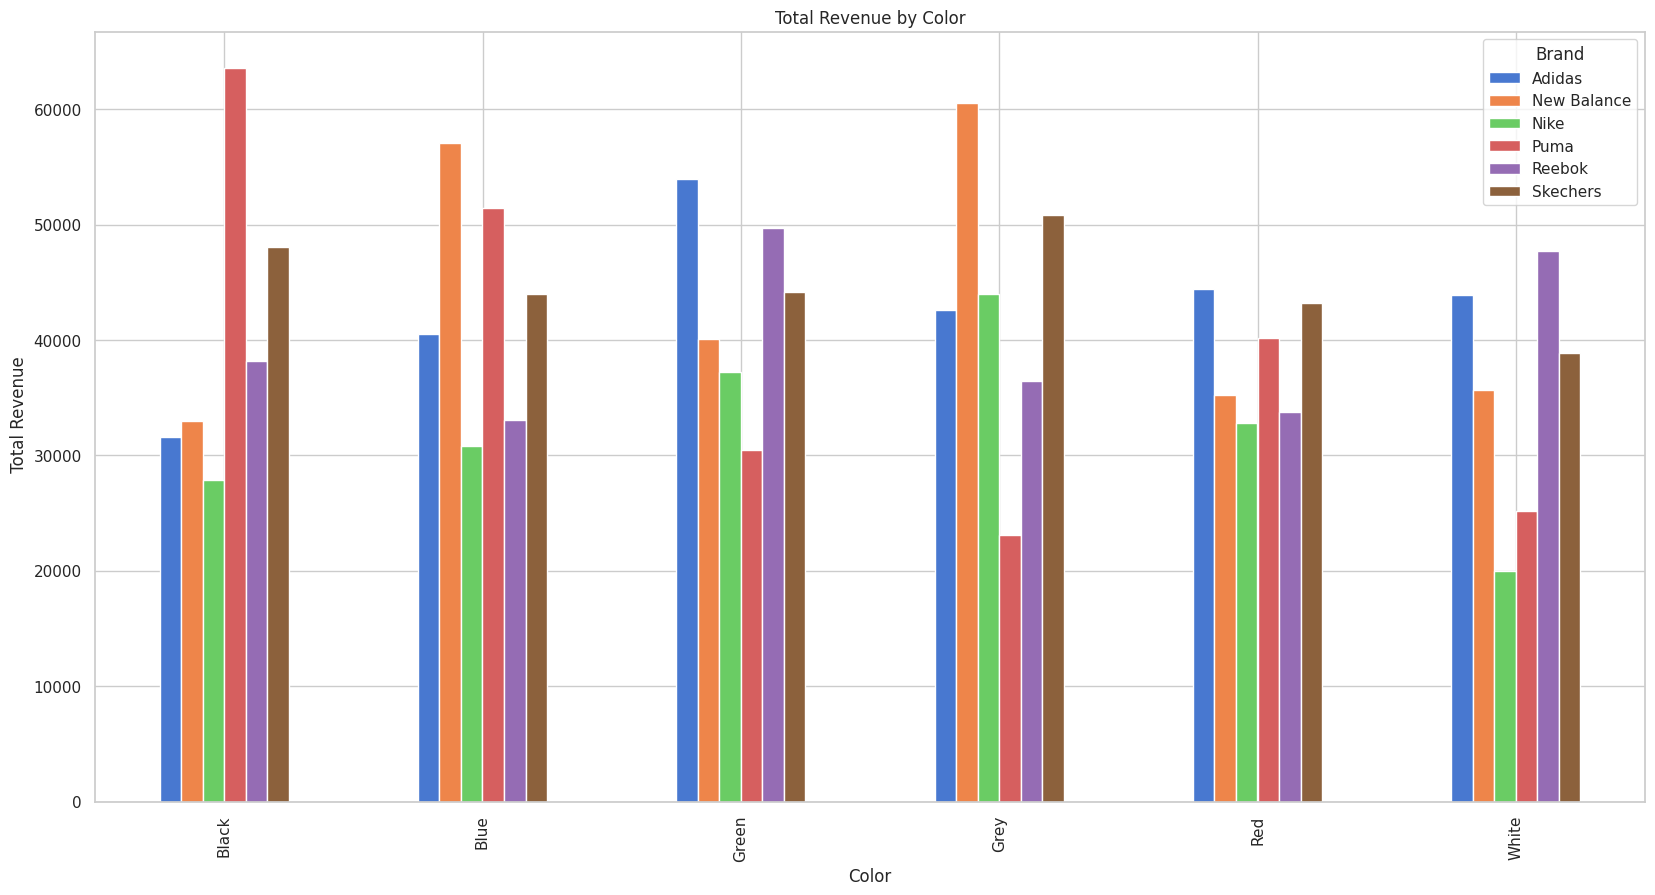

In [ ]:
n.plot(kind="bar", figsize=(20, 10))
plt.title("Total Revenue by Color")
plt.xlabel("Color")
plt.ylabel(" Total Revenue")
plt.grid(True)

In [ ]:
 df.groupby(["Color","Shoe_Type","Brand"])["Revenue_USD"].sum().unstack()

Brand              Adidas  New Balance      Nike      Puma    Reebok  Skechers
Color Shoe_Type                                                               
Black Boots       1466.34      8195.38   5962.84   9357.86   3699.28   7535.36
      Casual      2169.18      8366.88   3807.52  20129.83   4531.98   9357.05
      Formal      7727.94      5817.35   3205.97   9526.40   8925.31   4697.58
      Running     6681.57      2929.80   3620.00   7629.51   8172.09   8917.80
      Sneakers    8659.07      5060.58   8956.15   8851.66   6558.09   4601.68
      Sports      4897.36      2618.49   2288.66   8029.38   6262.70  12987.73
Blue  Boots       8763.84     17843.50   3220.24   9914.65   9230.13   6122.87
      Casual      8020.76      7546.79   3443.75   1204.31   1866.26   3492.34
      Formal      3975.53      8163.53   3641.84   9794.40   4513.83  11674.93
      Running     3567.37      5105.20   8562.90   6931.87   4639.59   4151.01
      Sneakers    7986.70      6631.53   7920.98   7003.85   4473.82  13928.07
      Sports      8199.47     11802.54   4065.36  16543.09   8376.60   4651.82
Green Boots      13579.75      3754.96   6361.08   7392.09       NaN   5804.03
      Casual      9397.01       458.43   2733.09   8050.39  18513.28   1732.87
      Formal      9441.27      7607.89  11845.35   6924.94   6710.08  15588.08
      Running     2948.44     10472.52   5032.16   3224.80   7515.28   8104.64
      Sneakers   11964.55     14244.25   8535.90   4355.39   6937.02   3485.28
      Sports      6637.13      3574.00   2750.10    484.67  10056.42   9398.88
Grey  Boots       5116.35     11556.46   8216.90   6728.34   7159.59  17651.86
      Casual      7725.63     11011.64   5373.43    815.15  14842.04   8315.57
      Formal      9256.42     15122.71   6356.50   2132.82   1742.25   3613.09
      Running     6627.09     11729.58   5857.38    415.70   4697.18  12013.77
      Sneakers    8561.07      7139.77  12948.52  11778.20   4760.54   4829.24
      Sports      5319.16      3966.72   5243.21   1231.66   3212.30   4423.94
Red   Boots      11235.47      7171.01   8601.81   3905.38   6510.44   5143.28
      Casual      5933.27      6887.75   7016.04   7929.82   5413.99   8419.33
      Formal      1197.16      6662.75    112.93   4373.84   8191.10   8768.78
      Running    16260.09      4128.07   6419.71   8122.08    521.58  10779.66
      Sneakers    8530.27      6230.91   3164.34   7452.45   9581.46   4210.15
      Sports      1280.76      4131.60   7490.67   8370.48   3521.70   5907.72
White Boots      10021.96      5697.94   1616.76   3756.82  11285.31  11000.21
      Casual      1499.50      5065.13   3939.12   2891.56   5335.09       NaN
      Formal      6955.74      7244.84   3903.63   4753.38  10498.41   3040.00
      Running     1740.56      4468.00    499.32   4790.61  12122.47  10454.29
      Sneakers   17977.44     11179.61   6385.64   3952.68   7491.71   6886.46
      Sports      5717.82      2043.57   3670.35   4999.53    958.02   7479.26

High-Yield Combinations (The Winners): Green Formal shoes emerge as a major revenue driver. Additionally, Grey Boots (highly driven by Skechers and New Balance) and Black Casual shoes (led by Puma at over 20,129) show exceptional market demand and premium revenue generation.

Low-Yield Combinations (The Underperformers): White Casual shoes and Black Boots generate remarkably low revenue across almost all brands (e.g., Adidas Black Boots yielding only 1,466), indicating low consumer preference for these specific item mixes.

Recommendation:

Double Down on High-Performers: Aggressively expand inventory allocation for Green Formal shoes, Grey & Blue Boots (leveraging Skechers/New Balance), and Black Casual lines from Puma to maximize high-margin sales.

Phase Out and Mitigate Low-Performers: Cut back orders for Black Boots across underperforming brands and reduce exposure to White Casual footwear. Reallocate that open inventory budget toward the dominant color palettes (Grey, Blue, and Green) to optimize stock turnover, eliminate shelf wastage, and boost overall gross margins.

In [ ]:
x = df.groupby("Sales_Channel")["Revenue_USD"].sum().sort_values(ascending=False)
x

,Revenue_USD
Sales_Channel,
Retail Store,506125.13
Mall,479288.58
Online,467772.32


Text(0, 0.5, 'Sales Channel')

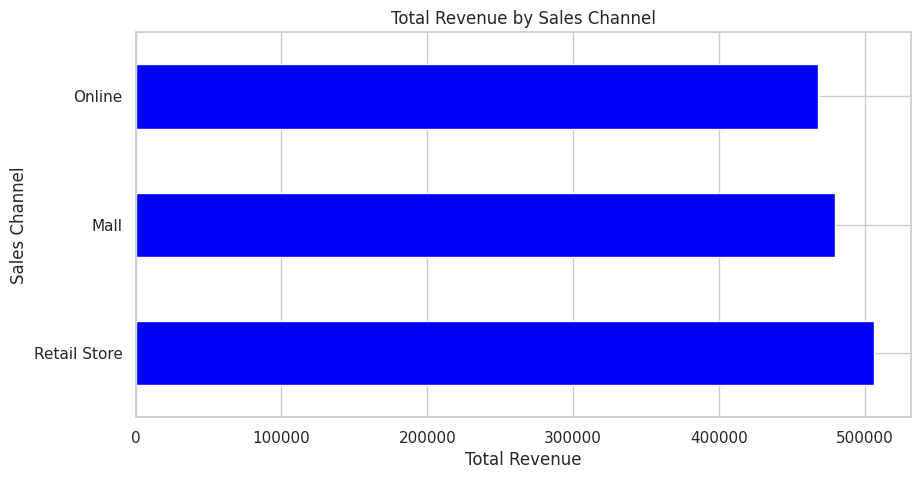

In [ ]:
x.plot(kind="barh", figsize=(10, 5),color="blue")
plt.title("Total Revenue by Sales Channel")
plt.xlabel("Total Revenue")
plt.ylabel("Sales Channel")

In [ ]:
p = df.groupby(["Sales_Channel","Brand"])["Revenue_USD"].sum().sort_values(ascending=False).unstack()
p

Brand,Adidas,New Balance,Nike,Puma,Reebok,Skechers
Sales_Channel,,,,,,
Mall,85262.98,72600.46,63757.64,74312.98,80209.51,103145.01
Online,61944.39,89030.10,72032.18,75464.61,80646.71,88654.33
Retail Store,109831.67,100001.12,56980.33,83972.00,77970.72,77369.29


In [ ]:
c = df.groupby(["Sales_Channel","Country"])["Revenue_USD"].sum().unstack().sort_values(ascending=False,by="Sales_Channel")
c

Country,France,Germany,India,Saudi Arabia,UAE,UK,USA
Sales_Channel,,,,,,,
Retail Store,86280.53,70235.99,64798.06,67820.82,70593.30,63340.29,83056.14
Online,68585.83,39675.66,54613.72,76368.23,98725.23,48905.50,80898.15
Mall,73212.68,89755.66,58547.98,46300.77,70489.02,74386.82,66595.65


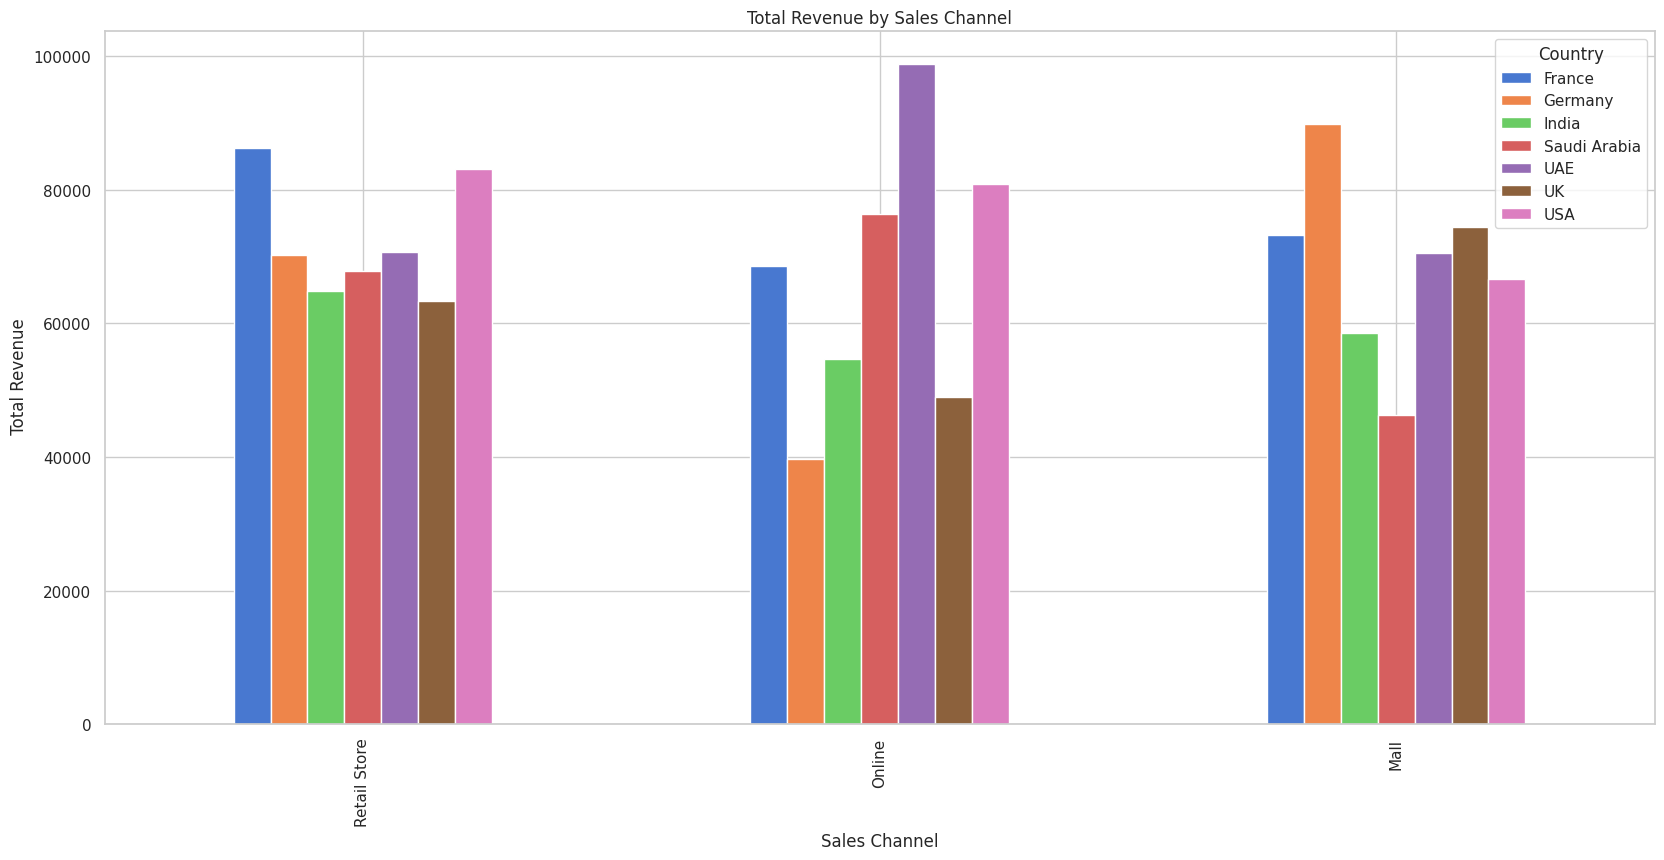

In [ ]:
c.plot(kind="bar", figsize=(20, 9))
plt.title("Total Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel(" Total Revenue")
plt.grid(True)

Digital Dominance: The Online channel delivers extraordinary, peak performance in the UAE and Saudi Arabia, demonstrating massive digital adoption and mature e-commerce penetration in the GCC region.

Brick-and-Mortar Preference: Consumers in Germany and the UK show a powerful, clear preference for Malls, while France and the USA sustain high-volume leadership via independent Retail Stores.

Recommendation:

Aggressive Digital Scaling: Maximize digital marketing spend, localized ad campaigns, and UI/UX optimization targeting the UAE and Saudi Arabian markets to ride the high-yielding online wave.

Physical Footprint Reinforcement: Expand stock allocation and premium display setups in German and UK Malls, while focusing on loyalty programs and in-store experiences within French and US Retail Stores.

Mitigating Germany's E-Commerce Gap: Investigate the massive online underperformance in Germany (under 40,000). Implement targeted web-only promotions or localized digital incentives to tap into the unrealized online potential of the German consumer base.

**Time analysis**

<Axes: xlabel='Month'>

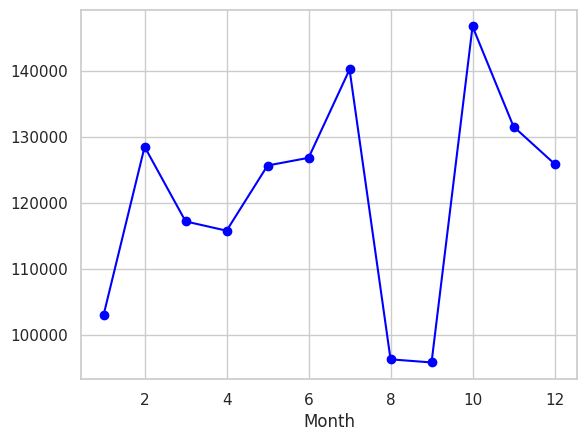

In [ ]:
df.groupby("Month")["Revenue_USD"].sum().plot(kind="line",color="blue",marker="o")

<Axes: xlabel='Quarter'>

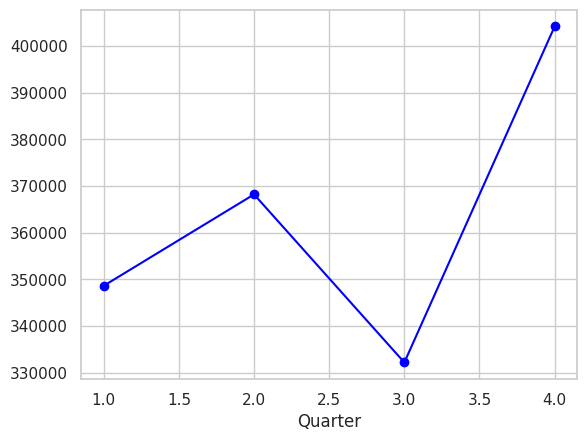

In [ ]:
df.groupby("Quarter")["Revenue_USD"].sum().plot(kind='line',color="blue",marker="o")



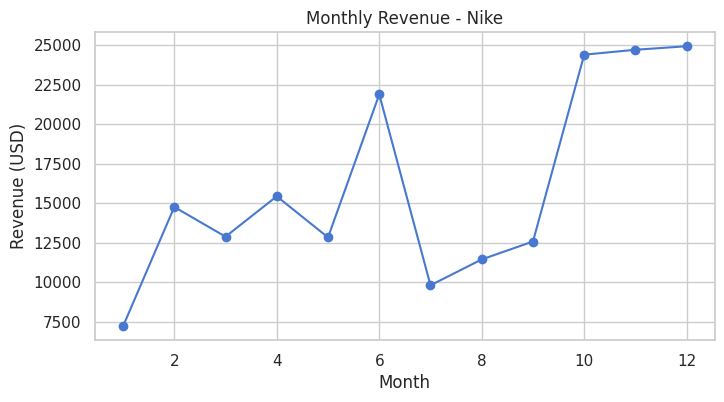

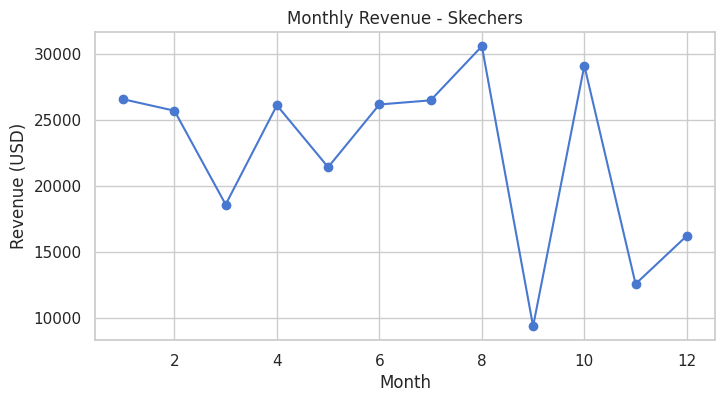

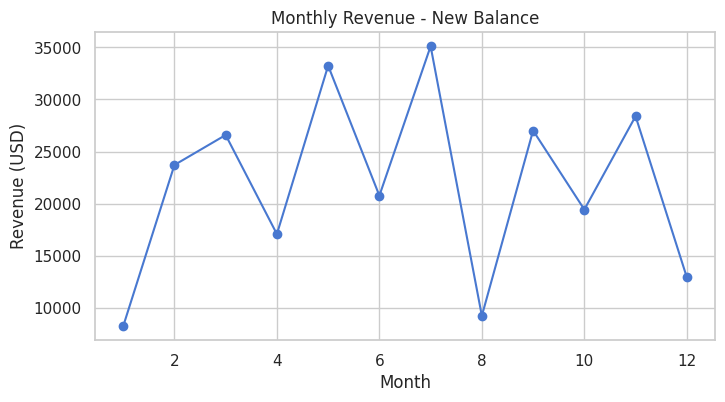

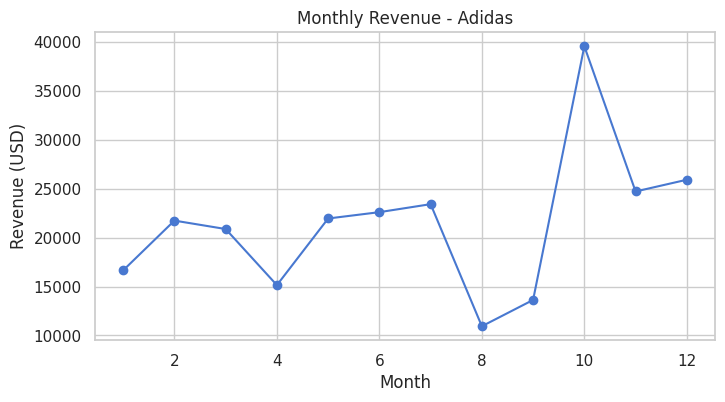

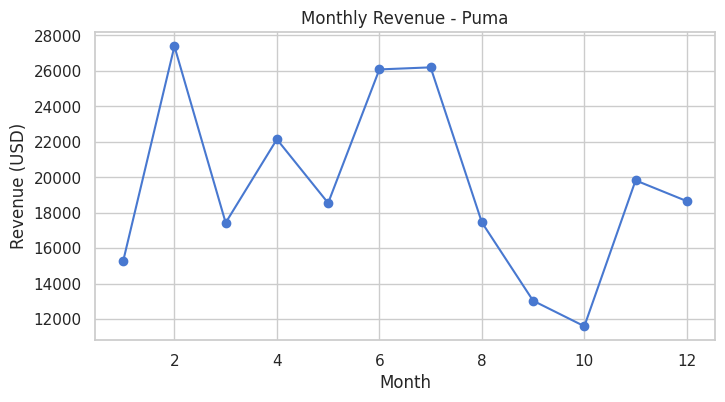

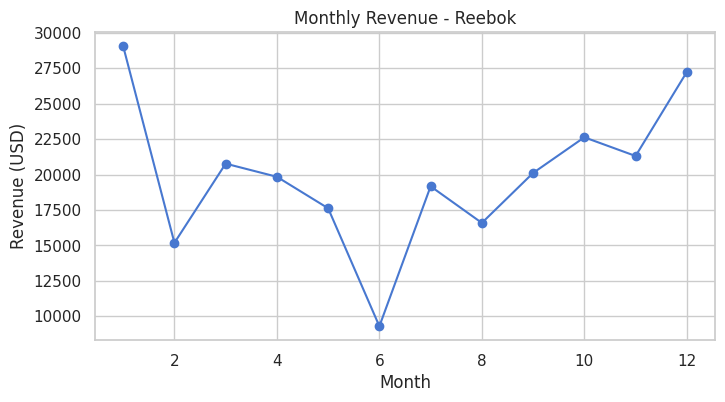

In [ ]:
for brand in df["Brand"].unique():
    plt.figure(figsize=(8,4))

    df[df["Brand"] == brand] \
        .groupby("Month")["Revenue_USD"] \
        .sum() \
        .plot(marker="o")

    plt.title(f"Monthly Revenue - {brand}")
    plt.xlabel("Month")
    plt.ylabel("Revenue (USD)")
    plt.grid(True)

Based on the analysis of the brand sales charts, here are the strategic and marketing recommendations to improve revenue and inventory management:

1. Capitalizing on Peak Seasons
Focus efforts on the Fourth Quarter (Q4): The data shows that the fourth quarter is by far the strongest, with total revenue exceeding $400,000. This is mainly driven by the massive surge for Adidas in October (Month 10), approaching $40,000, and the strong, steady growth for Nike in the last three months of the year, with sales hovering around $25,000.

Recommendation: Allocate the largest share of paid advertising budgets and year-end promotions (such as Black Friday) to this period.

Invest in the summer recovery wave: New Balance experiences a strong surge and peaks in July (Month 7), exceeding $35,000, while Skechers achieves its highest sales in August (Month 8), crossing the $30,000 mark.

Recommendation: Launch marketing campaigns for comfortable summer shoes, travel, and trips starting from May to align with this upward trend.

2. Managing Cyclical Slumps and Inventory
Countering the sharp August slump: A sudden and significant decline is observed for several brands in August (Month 8); New Balance sales drop below $10,000, and Adidas falls to its lowest levels around $11,000, negatively impacting the overall sales curve.

Recommendation: Avoid overordering new inventory from these companies in August. Instead, rely on "Back to School" promotions and summer clearances to liquidate current stock.

Addressing the Skechers decline in September and November: Skechers sales drop significantly in September (Month 9) to below $10,000, and this slowdown repeats in November (Month 11).

Recommendation: Revitalize sales during these slow months by offering exclusive deals (such as product bundles or free shipping) to incentivize buyers.

3. Brand Positioning and Ad Rotation
Relying on Nike as a core pillar: Nike is characterized by highly stable and consistent growth in the second half of the year, specifically from October to December.

Recommendation: Secure sufficient inventory of Nike in advance to guarantee a stable and assured cash flow during the final quarter.

Smart rotation between Puma and Reebok: Puma achieves excellent sales in February (Month 2) and at the beginning of summer (June and July), whereas Reebok starts the year very strong in January (Month 1), then declines before bouncing back again in December.

Recommendation: Create a rotation schedule for product displays; highlight Puma on the storefront in February and during the summer, and shift the advertising focus to Reebok in January and at the end of the year.

# Nouvelle section


**The probleme:**
**The store's inability to accurately predict monthly sales volumes for each individual brand based on temporal factors and seasonality, leading to poor inventory management and fluctuating profits.**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [ ]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD', 'Quarter',
       'Year', 'Month'],
      dtype='object')

In [ ]:
# 1. ترتيب البيانات زمنياً لضمان أن بايثون يفهم تسلسل الأشهر والسنوات
df = df.sort_values(by=['Brand', 'Country', 'Year', 'Month']).reset_index(drop=True)

# 2. إنشاء ميزة الـ Lag الفعالة (إيرادات الشهر السابق)
# هذه الميزة ستعلم النموذج كم كانت مبيعات الماركة في نفس الدولة الشهر الماضي كمؤشر أساسي
df['Last_Month_Revenue'] = df.groupby(['Brand', 'Country'])['Revenue_USD'].shift(1)

# تعبئة قيم الشهر الأول (التي ستكون فارغة NaN) بمتوسط إيرادات تلك الماركة
df['Last_Month_Revenue'] = df.groupby('Brand')['Last_Month_Revenue'].transform(lambda x: x.fillna(x.mean()))

# 3. الآن نقوم بترميز الميزات النصية كالمعتاد
df_encoded = pd.get_dummies(df, columns=['Brand', 'Sales_Channel', 'Shoe_Type', 'Color', 'Country', 'Sale_ID'], drop_first=True)

# 4. تحديد المتغيرات (مع استبعاد الأعمدة غير الرقمية وعمود الهدف)
X = df_encoded.drop(columns=["Revenue_USD", "Date"], axis=1)
y = df_encoded["Revenue_USD"]

# 5. إعادة تقسيم البيانات
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
df.dtypes

,0
Sale_ID,object
Date,datetime64[ns]
Brand,object
Shoe_Type,object
Color,object
Country,object
Sales_Channel,object
Price_USD,float64
Units_Sold,int64
Revenue_USD,float64


In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [ ]:
model.score(X_train, Y_train)

0.9994096025168697

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(Y_test, y_pred)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

Mean Absolute Error (MAE): $52.42


In [ ]:
r2 = r2_score(Y_test, y_pred)
print(f"R2 Score (Model Accuracy): {r2 * 100:.2f}%")

R2 Score (Model Accuracy): 99.54%


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, Y_train)

y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost R2 Score: {r2_score(Y_test, y_pred_xgb) * 100:.2f}%")

XGBoost R2 Score: 99.65%
